# Baseline Survival Analysis

- Random Forest Survival Model
- Gradient Boosted Survival Model
- Survival SVM

## Random Forest Survival Model

In [1]:
import pandas as pd
from sksurv.datasets import get_x_y
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import (concordance_index_censored,
                            cumulative_dynamic_auc)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import shap

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from utils.deephit_preprocessor import DeepHitPreprocessor


c:\Users\GARETHE\Projects\Personal-Website\Injury Prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1. Read in and filter data
injury_dataset = pd.read_parquet("../data/deephit_ready_dataset.parquet")

injury_dataset = injury_dataset[
    injury_dataset["player_name"].str.contains("TeamB", na=False)
].copy()

In [8]:
# # reading in data
# injury_dataset = pd.read_parquet("../data/deephit_ready_dataset.parquet")

# injury_dataset = injury_dataset[
#     injury_dataset["player_name"].str.contains("TeamB", na=False)
# ]

# Ensure date is datetime type
injury_dataset['date'] = pd.to_datetime(injury_dataset['date'])

# Sort chronologically per player (CRITICAL for valid moving averages)
injury_dataset = injury_dataset.sort_values(by=['player_name', 'date']).reset_index(drop=True)

# 2. Identify metadata vs. feature columns
# We do not want to take a rolling average of targets or player names
meta_cols = ['player_name', 'date', 'is_injured_today', 'injury_onset', 'event', 'duration']
feature_cols = [col for col in injury_dataset.columns if col not in meta_cols]

# 3. Calculate the 21-day moving average per player
print("Calculating 21-day moving averages per player...")
rolling_features = (
    injury_dataset.groupby('player_name')[feature_cols]
    .rolling(window=21, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True) # Drops the groupby multi-index
)

# Optional but recommended: Rename columns to reflect the transformation 
# (e.g., matching the SHAP plot features in the paper)
# rolling_features.columns = [f"{col}_mean_21d" for col in rolling_features.columns]

# 4. Recombine metadata with the new rolling features
injury_dataset = pd.concat([injury_dataset[meta_cols], rolling_features], axis=1)

print("Moving averages calculated successfully.")

Calculating 21-day moving averages per player...
Moving averages calculated successfully.


In [9]:
# data splitting
# Get a list of all unique players in the dataset
unique_players = injury_dataset['player_name'].unique()
print(f"Starting LOPO Validation across {len(unique_players)} players...\n")

Starting LOPO Validation across 31 players...



In [10]:
def plot_inline_lopo_risk(player_id, dates, predicted_risk, injury_dates, c_index):
    """
    Plots the predicted risk and actual injury markers for a single player.
    """
    plt.figure(figsize=(12, 5))
    
    # Plot the continuous risk line
    plt.plot(dates, predicted_risk, label='Predicted Risk', color='#1f77b4', linewidth=2)
    
    # Draw the vertical line for the actual injury (using the duration == 1 filter)
    for idx, inj_date in enumerate(injury_dates):
        label = 'Actual Injury' if idx == 0 else ""
        plt.axvline(x=inj_date, color='red', linestyle='--', linewidth=2, label=label)
        plt.axvspan(inj_date - pd.Timedelta(days=7), inj_date, color='red', alpha=0.1, label='7-Day Window' if idx==0 else "")
    
    # Formatting
    plt.title(f'LOPO Predicted Injury Risk\nPlayer: {player_id}', fontsize=12, fontweight='bold')
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Risk Score', fontsize=11)
    
    # Add C-index text box
    plt.text(0.01, 0.02, f"C-index: {c_index:.3f}", transform=plt.gca().transAxes, 
             fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_shap_summary(model, X_train, X_test, player_id):
    """
    Calculates SHAP values using a model-agnostic explainer and generates a summary plot.
    """
    # Create a background dataset to speed up calculation
    # We take a random sample of 50 rows from the training data to act as the baseline.
    # (If calculating takes too long, you can reduce this number, but 50 is a good balance).
    background = shap.sample(X_train, 50)
    
    # Initialize the KernelExplainer (Black-box explainer)
    # We pass the model's prediction function and the background dataset
    explainer = shap.KernelExplainer(model.predict, background)
    
    # Calculate SHAP values for the held-out player
    # We use silent=True to prevent it from printing a progress bar for every single player
    shap_values = explainer.shap_values(X_test, silent=True)
    
    # Generate the plot
    plt.figure(figsize=(10, 6))
    
    # shap.summary_plot automatically renders the plot to the current matplotlib figure
    shap.summary_plot(shap_values, X_test, show=False)
    
    # Add title and formatting
    plt.title(f"SHAP Feature Impact on Predicted Risk\nPlayer: {player_id}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

Starting LOPO Validation across 31 players...

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[1/31] Player TeamB-08... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[2/31] Player TeamB-10... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[3/31] Player TeamB-24... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[4/31] Player TeamB-29... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[5/31] Player TeamB-2f... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[6/31] Player TeamB-38... | In

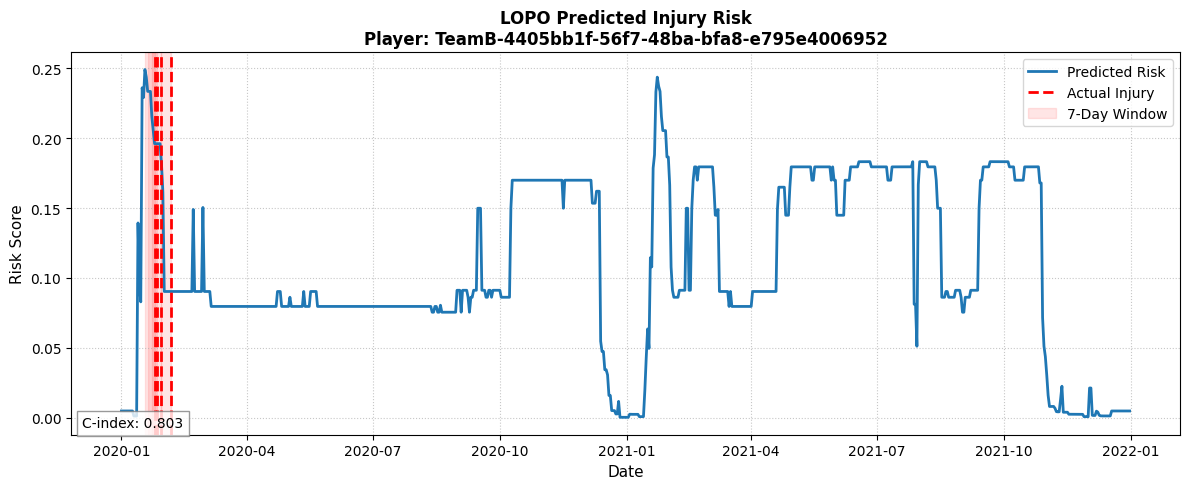

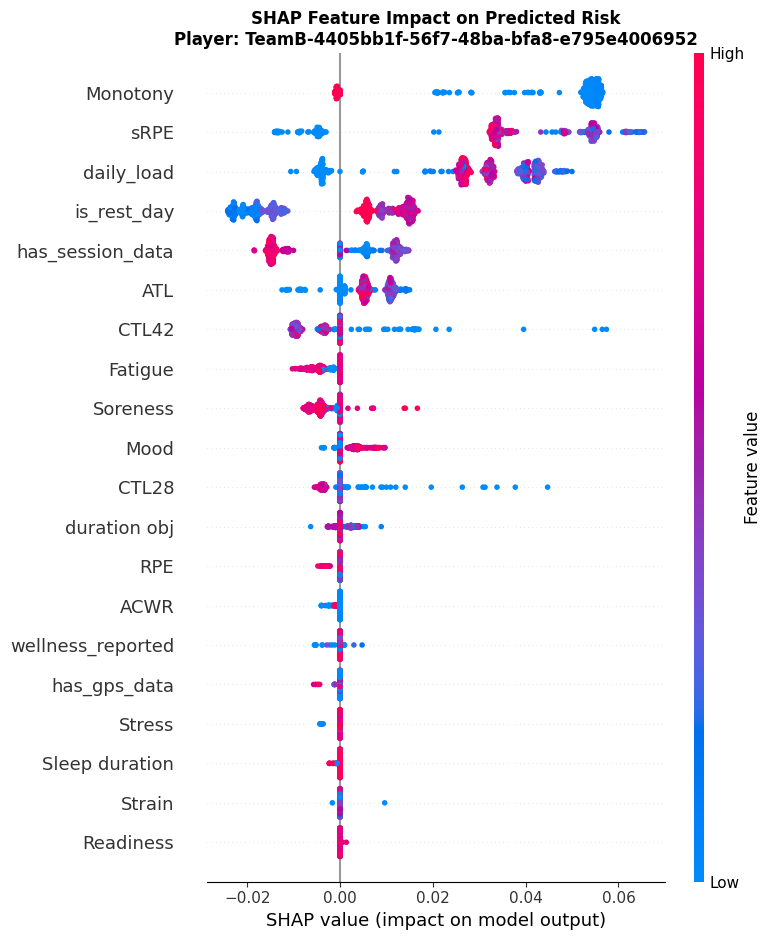

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[8/31] Player TeamB-48... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[9/31] Player TeamB-4b... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[10/31] Player TeamB-4d... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[11/31] Player TeamB-5a... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[12/31] Player TeamB-5e... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[13/31] Player TeamB-6d... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitt

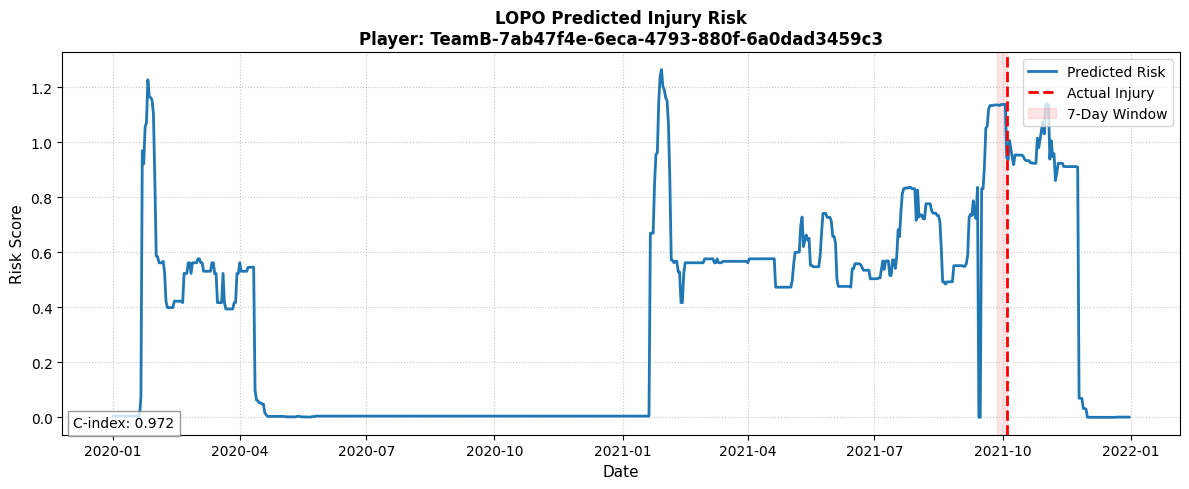

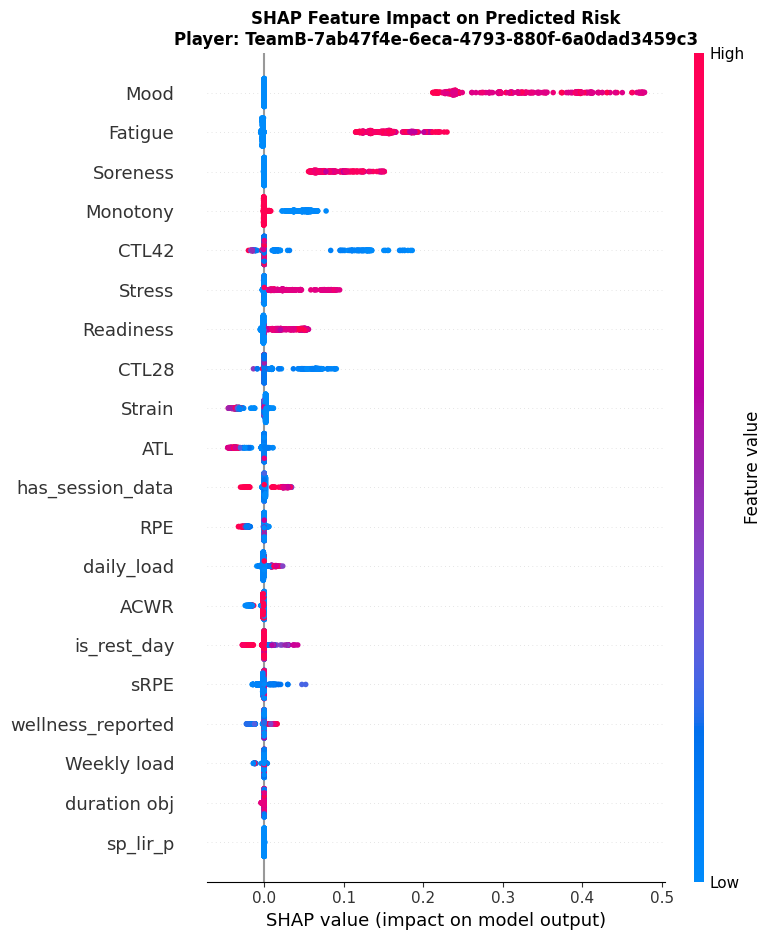

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[17/31] Player TeamB-7d... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[18/31] Player TeamB-8d... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[19/31] Player TeamB-9c... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[20/31] Player TeamB-a3... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[21/31] Player TeamB-a7... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[22/31] Player TeamB-ab... | Injuries: 0 | C-index: N/A (No events)
🔧 Fi

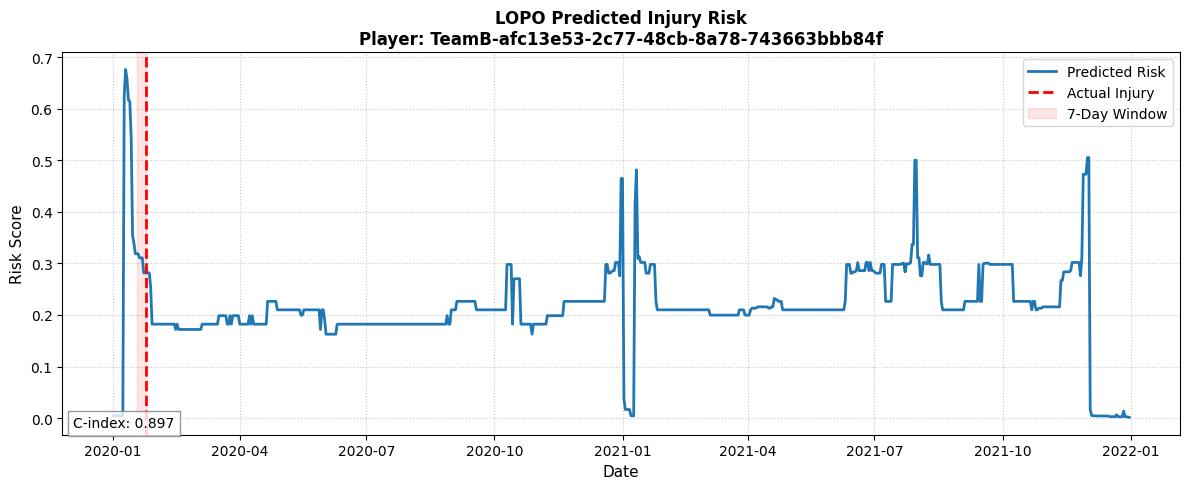

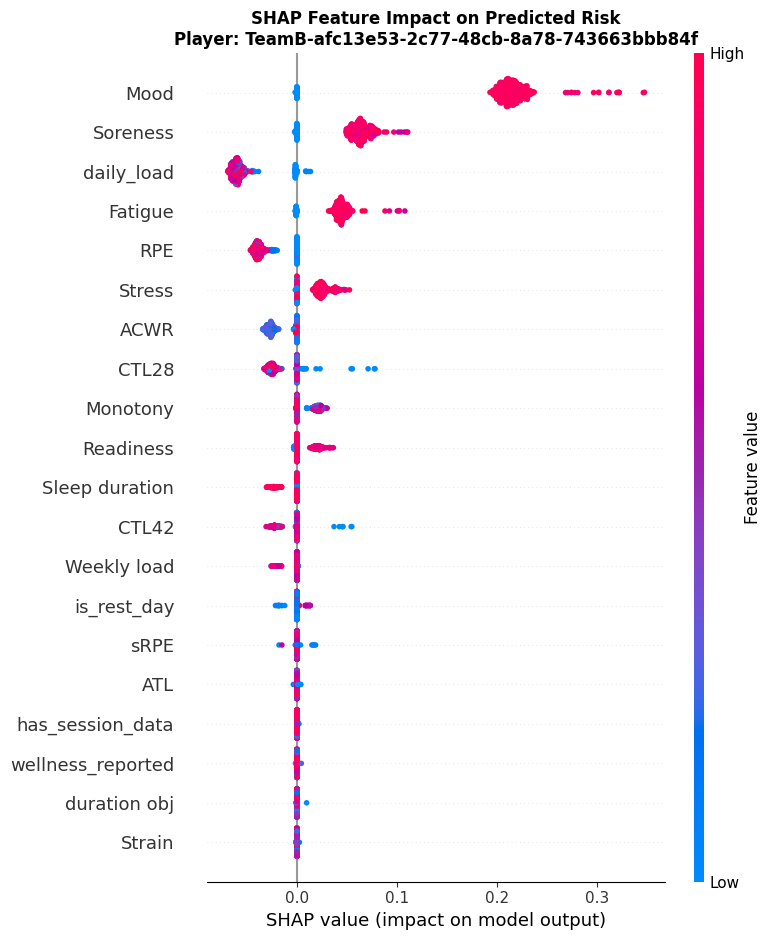

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[25/31] Player TeamB-ba... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[26/31] Player TeamB-d9... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[27/31] Player TeamB-e0... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[28/31] Player TeamB-e1... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[29/31] Player TeamB-e4... | Injuries: 14 | C-index: 0.505


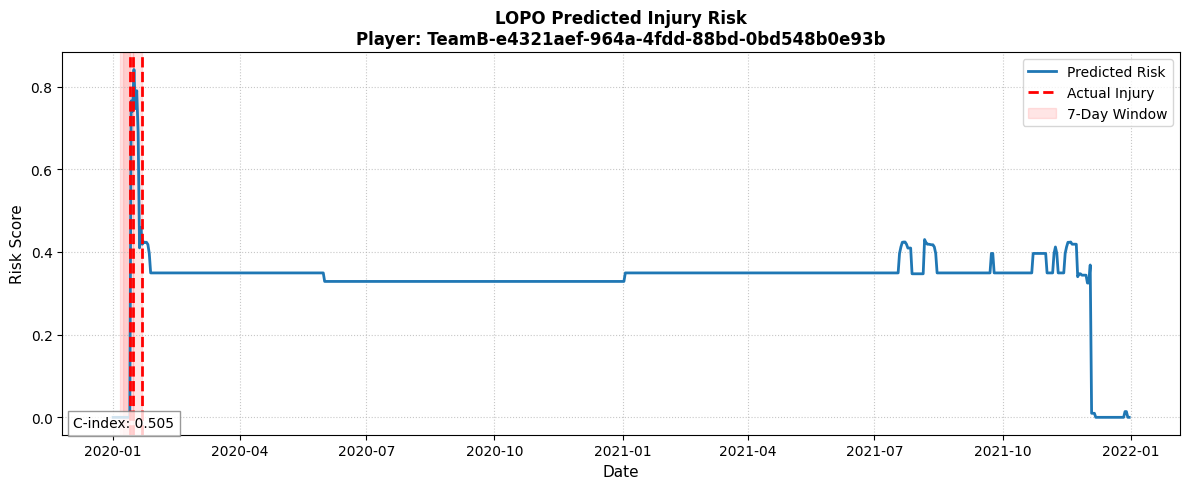

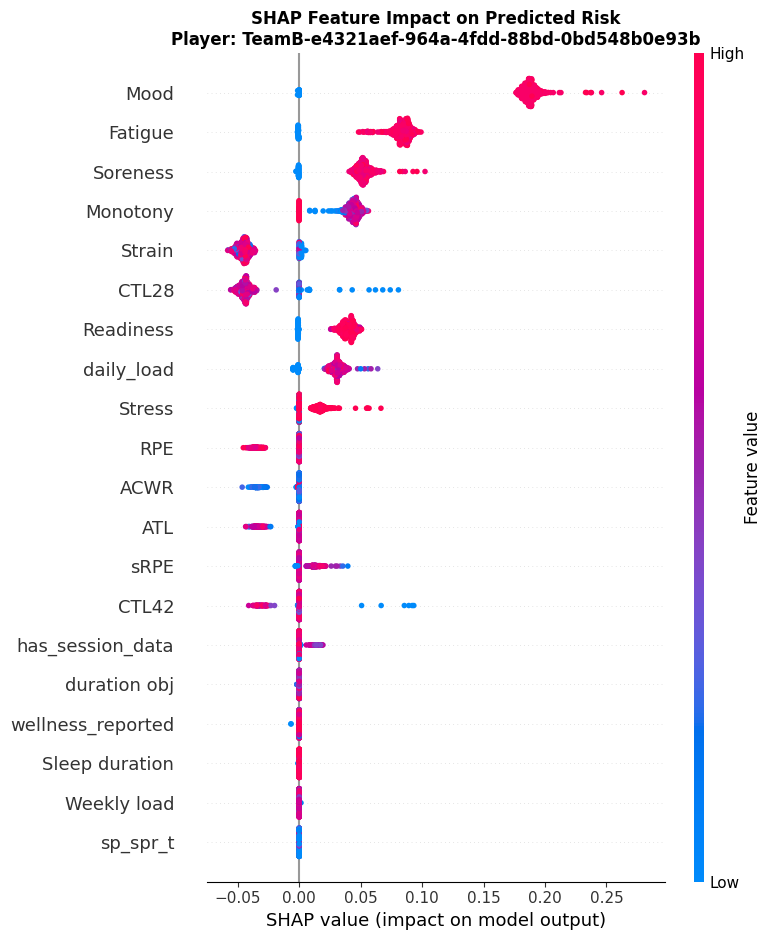

🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[30/31] Player TeamB-eb... | Injuries: 0 | C-index: N/A (No events)
🔧 Fitting preprocessor safely on Training Data...
🚀 Applying safe transformations to Test Data...
[31/31] Player TeamB-f6... | Injuries: 0 | C-index: N/A (No events)

LOPO VALIDATION COMPLETE
Total injured players evaluated: 4
Average LOPO C-index: 0.794
Median LOPO C-index: 0.850
Interquartile Range (IQR): 0.187


In [11]:
lopo_c_indices = []

rsf = RandomSurvivalForest(n_estimators=100, 
                           min_samples_split=10, 
                           min_samples_leaf=15, 
                           n_jobs=-1,
                           random_state=8)

print(f"Starting LOPO Validation across {len(unique_players)} players...\n")

# --- 3. The LOPO Loop ---
for i, test_player in enumerate(unique_players):
    
    # a) Split the data
    df_train = injury_dataset[injury_dataset['player_name'] != test_player].copy()
    df_test = injury_dataset[injury_dataset['player_name'] == test_player].copy()
    
    # Sort df_test chronologically so the predicted array aligns with dates
    df_test = df_test.sort_values('date')

    # process data (scaling and clipping)
    preprocessor = DeepHitPreprocessor()
    df_train_scaled = preprocessor.fit_transform(df_train)
    df_test_scaled = preprocessor.transform(df_test)
    
    # b) Extract X and y, dropping metadata
    drop_cols = ['player_name', 'date']
    
    X_train, y_train = get_x_y(df_train_scaled.drop(columns=drop_cols), 
                               attr_labels=['event', 'duration'], pos_label=1, survival=True)
    X_test, y_test = get_x_y(df_test_scaled.drop(columns=drop_cols), 
                             attr_labels=['event', 'duration'], pos_label=1, survival=True)
    
    # c) Train the model on the rest of the squad
    rsf.fit(X_train, y_train)
    
    # d) Evaluate and Plot (only if they had an injury)
    injury_count = y_test['event'].sum()
    
    if injury_count > 0:
        # Calculate score
        c_index = rsf.score(X_test, y_test)
        lopo_c_indices.append(c_index)
        print(f"[{i+1}/{len(unique_players)}] Player {test_player[:8]}... | Injuries: {injury_count} | C-index: {c_index:.3f}")
        
        # --- GENERATE PLOT DATA ---
        predicted_risk = rsf.predict(X_test)
        
        # Filter for the exact date of the injury (event == 1 AND duration == 1)
        injury_dates = df_test[(df_test['event'] == 1) & (df_test['duration'] == 1)]['date']
        
        # Call the plotting helper function
        plot_inline_lopo_risk(player_id=test_player, 
                              dates=df_test['date'], 
                              predicted_risk=predicted_risk, 
                              injury_dates=injury_dates, 
                              c_index=c_index)

        # Plot the SHAP Explanation
        # We pass the X_test matrix (which only contains numeric features)
        plot_shap_summary(model=rsf, X_train=X_train, X_test=X_test, player_id=test_player)
                              
    else:
        print(f"[{i+1}/{len(unique_players)}] Player {test_player[:8]}... | Injuries: 0 | C-index: N/A (No events)")

# --- 4. Final Aggregated Results ---
print("\n" + "="*40)
print("LOPO VALIDATION COMPLETE")
print("="*40)
print(f"Total injured players evaluated: {len(lopo_c_indices)}")
print(f"Average LOPO C-index: {np.mean(lopo_c_indices):.3f}")
print(f"Median LOPO C-index: {np.median(lopo_c_indices):.3f}")

if len(lopo_c_indices) > 0:
    q75, q25 = np.percentile(lopo_c_indices, [75, 25])
    print(f"Interquartile Range (IQR): {q75 - q25:.3f}")

So what does this mean?

For a given leave one out player:
"If I randomly select one healthy day and one pre-injury day from this specific player's season, there is an 80% chance my model correctly assigned a higher risk score to the pre-injury day."

This means, on average, the model gives a very good look at quantifying player risk factor.